# Проверка гипотезы для менеджеров Яндекс.Книги, составление аналитической записки

- Автор: Казанцев Павел

## Цели и задачи проекта

**Целью проекта** является проверка предполагаемой гипотезы о лояльности пользователей из Санкт-Петербурга и Москвы сервиса Яндекс.Книги. 

**Гипотеза заключается в том**, что пользователи, которые приносят больший LTV, являются более лояльными, а значит, проводят в среднем больше времени за чтением и прослушиванием книг в приложении.

В качестве данных была взята выгрузка из БД Яндекс.Книги, описание данных ниже. 

**Нулевая гипотеза** $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

**Альтернативная гипотеза** $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

## Описание данных

Используется выгрузка данных из БД Яндекс.Книги.

Датасет `yandex_knigi_data.csv` - таблица с данными об активности пользователей из Москвы и Санкт-Петербурга.

- `city` - город пользователя
- `puid` - идентификатор пользователя
- `hours` - сумма часов чтения и прослушивания

## Содержимое проекта
1. Загрузка данных
    - Проверка данных на наличие дубликатов и пропусков в столбце `puid`.
    - Проверка данных на аномалии и выбросы
2. Проверка гипотезы при помощи стат. теста
3. Аналитическая записка по результатам исследования


---

## 1. Загрузка данных

Загрузка данных пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Установка библиотеки для форматирования кода
%pip install jupyter_black

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Загрузка библиотек для работы
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jupyter_black
from scipy import stats
from scipy.stats import ttest_ind

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)
jupyter_black.load()

In [4]:
# Загрузка датасета
data = pd.read_csv(
    "https://code.s3.yandex.net/datasets/yandex_knigi_data.csv", index_col=0
)

In [5]:
data.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB


Датасет имеет 3 столбца и 8784 строки. Во всех столбцах отсутсвтуют пропуски. Данные представленны в корректном типе данных, за ислючением их разрядности.

### 1.1 Проверка данных пользователя на дубликаты

In [7]:
# Проверка на полные дубликаты
data.duplicated().sum()

np.int64(0)

Полных дубликатов в данных нет

In [8]:
# Проверка на неявные дубликаты по id пользователя
data.duplicated(subset="puid").sum()

np.int64(244)

Неявные дубликаты по id пользователя обнаружены в размере 244 единиц

In [9]:
# Соберем все дублирующиеся значния id
duplicate_id = data[data.duplicated(subset="puid")]["puid"].unique().tolist()

# Проверим природу дублей
data[data["puid"].isin(duplicate_id)].sort_values(by="puid")

,city,puid,hours
6247,Санкт-Петербург,2637041,3.883926
35,Москва,2637041,10.317371
134,Москва,9979490,32.415573
6274,Санкт-Петербург,9979490,1.302997
145,Москва,10597984,42.931506
...,...,...,...
8773,Санкт-Петербург,1130000020425037,2.386944
6202,Москва,1130000023864516,142.830085
8775,Санкт-Петербург,1130000023864516,14.384722
8779,Санкт-Петербург,1130000028554332,4.107774


Можем наблюдать, что один и тоже id есть в двух группах (МСК и СПб). Это указывает на пересечение групп. Проверим, действительно ли дубли - это пересекающиеся значения:

In [10]:
moscow = data[data["city"] == "Москва"]["puid"]
spb = data[data["city"] == "Санкт-Петербург"]["puid"]

# Cписок id пользователей, которые попали в обе группы
cross_id = list(set(moscow) & set(spb))

# Проверим, что дублирующиеся значения совпадают с пересекащимися значениями
print(set(duplicate_id) == set(cross_id))

# Дубли внутри каждой группы
moscow_dups = data[data["city"] == "Москва"]["puid"].duplicated().sum()
spb_dups = data[data["city"] == "Санкт-Петербург"]["puid"].duplicated().sum()

print(moscow_dups, spb_dups)

True
0 0


Есть подтверждение, что **дубли id - это пересекающиеся значения между городами** и внутри групп дублей нет.

Для корректности результатов А/B-теста группы должны быть независимыми, то есть один и тот же пользователь должен быть только в одной группе. В данном случае требуется исключить пересекающиеся id из данных.

In [12]:
print(
    f"Какой % данных потеряется при исключении пересечений: {round(len(cross_id) / data['puid'].nunique() * 100, 2)}%"
)

# Исключим пересечения из датасета
data = data[~data["puid"].isin(cross_id)].copy()

Какой % данных потеряется при исключении пересечений: 2.86%


Возможные причины пересечения:
- Пользователь мог переехать / сменить город в профиле → попал в обе группы
- Геолокация по IP нестабильна

### 1.2 Проверка данных на аномалии и выбросы

In [13]:
data.groupby("city")["hours"].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Москва,5990.0,10.848192,36.925622,0.000022,0.057042,0.888232,5.933439,857.209373
Санкт-Петербург,2306.0,11.264433,39.831755,0.000025,0.060173,0.875355,6.138424,978.764775


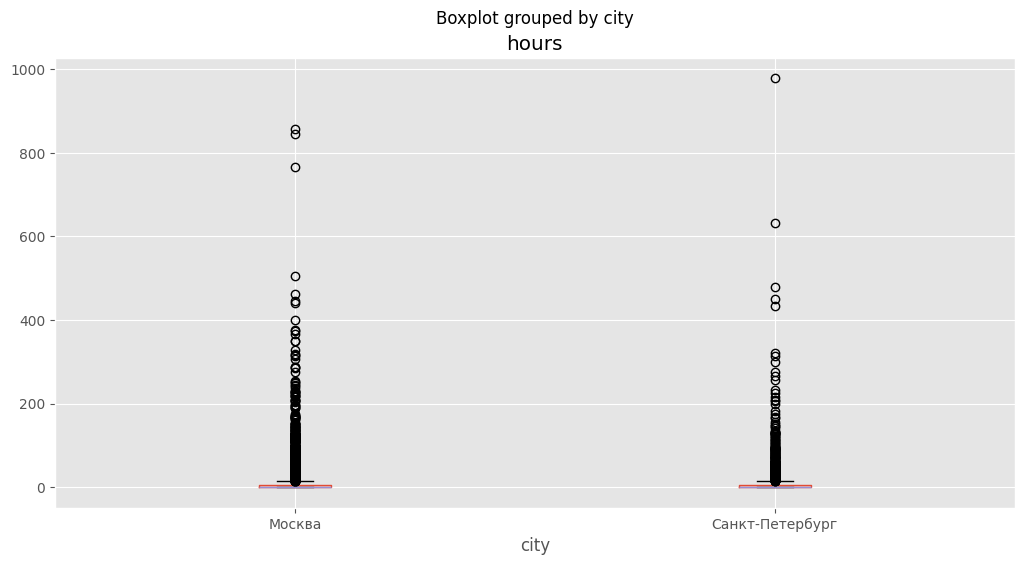

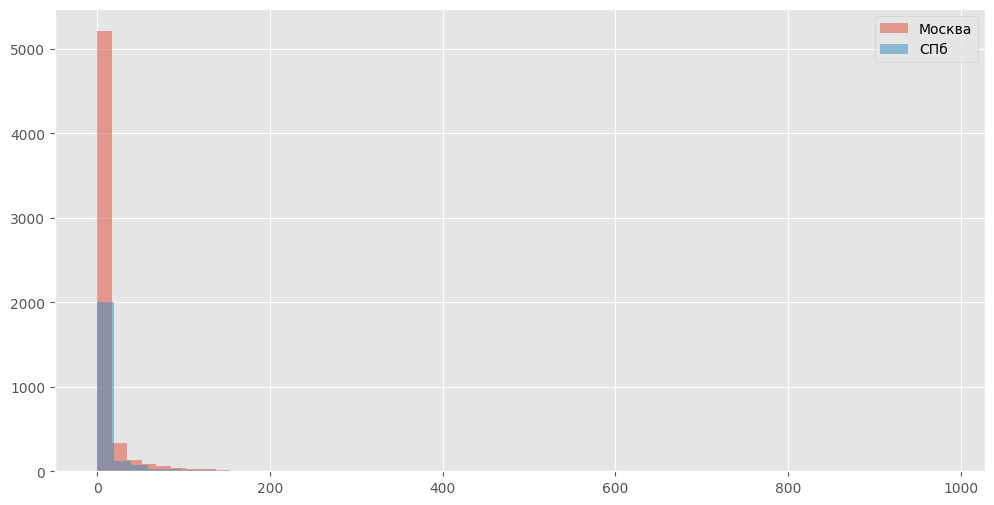

In [14]:
data.boxplot(column="hours", by="city")
plt.show()

data[data.city == "Москва"]["hours"].hist(bins=50, alpha=0.5, label="Москва")
data[data.city == "Санкт-Петербург"]["hours"].hist(bins=50, alpha=0.5, label="СПб")
plt.legend()
plt.show()

- Средние почти равны, медианы тоже почти равны.
- Выборки разного размера (Москва 5990 vs 2306 Санкт-Петербург)
- Стандартное отклонение огромное (37 и 40) — в 3.5 раза больше среднего. Дисперсии не равны.
- Максимум ~857–979 часов, тогда как медиана < 1 часа. Это сильно скошенное вправо распределение: большинство пользователей почти не читают/не слушают, а среднее вытягивают единичные «киты».

## 2. Проверка гипотезы

**Гипотеза звучит так**: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. 
При проверке статистической значимости различия будет использоваться двухвыборочный t-test Уэлча:

- $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$. Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$. Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [15]:
diff_activity = (
    data[data["city"] == "Санкт-Петербург"]["hours"].mean()
    - data[data["city"] == "Москва"]["hours"].mean()
)

print(
    f"Разница в средней активности пользователя между МСК и СПб = {diff_activity:.4f} часа"
)

Разница в средней активности пользователя между МСК и СПб = 0.4162 часа


Теперь с помощью t-test Уэлча проверим, насколько статистически значимо такое различие

In [16]:
# Уровень значимости альфа
alpha = 0.05

# Две выборки по городам
msk = data[data["city"] == "Москва"]["hours"]
spb = data[data["city"] == "Санкт-Петербург"]["hours"]

# Проводим t-test Уэлча
t_stat, pvalue = stats.ttest_ind(spb, msk, equal_var=False, alternative="greater")

print(f"pvalue = {pvalue:.5f}")

if pvalue > alpha:
    print(
        f"Недостаточно данных, чтобы отклонить нулевую гипотезу. Разница в среднем времени активности между городами статистически не значима"
    )
else:
    print(
        f"Альтернативная гипотеза находит подтверждение. Разница в среднем времени активности между городами статистически значима, в СПб выше"
    )

pvalue = 0.33180
Недостаточно данных, чтобы отклонить нулевую гипотезу. Разница в среднем времени активности между городами статистически не значима


## 3. Аналитическая записка

**Метод**
- Для проверки гипотезы о различии в среднем времени активности пользователей между Москвой и СПб использован t-тест Уэлча (неравные размеры групп: 5990 и 2306; неравные дисперсии; скошенность распределений компенсируется большим объёмом выборок согласно ЦПТ). Уровень значимости α = 0.05.

    - $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.
    - $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

**Результаты**
- Средняя активность: Москва = 10.848 ч, СПб = 11.264 ч.

- Разница средних: +0.416 ч в пользу СПб.

- t-тест Уэлча: p-value = 0.33.

**Интерпретация**

- p-value = 0.33 > α = 0.05. Это означает: если бы среднее время активности в СПб не превышала московскую, вероятность получить выборочную разницу 0.416 ч и более составила бы ~33%. Это не редкость, поэтому данные не противоречат нулевой гипотезе - оснований отвергнуть H₀ нет.

**Выводы и причины, объясняющие полученные результаты**

- Статистически значимых различий не обнаружено. Это может объясняться как схожестью потребительского поведения аудитории (ср.временем активности) в двух городах, так и недостаточной мощностью теста для эффекта такого размера на фоне сильно скошенного распределения метрики и наличия значимых выбросов.
- Также стоит сказать, что это не А/В тест, а сравнение двух реальных городов. Даже при наличии стат. значимой разницы, нельзя сказать, что определенный город влияет на активность именно из-за бОльшего LTV пользователя. Кроме этого нужно учитывать и категориальные признаки пользователей, которые в исследовании не используются.